What you need to do:

    Data Preparation
        Load and merge pokemon.csv and combats.csv.
        Fix missing values:
            Fill the missing Name for Pokemon #62 (Primeape).
            Handle NaN values in Type 2 (mark as “None” if missing).
        Calculate each Pokemon’s win percentage using the combat data.

    Exploratory Analysis & Visualization
        Create a correlation matrix to identify relationships between stats (HP, Attack, Speed) and win percentage.
        Plot a Seaborn pairplot or PairGrid for stats vs. win percentage.
        Analyze the top 10 Pokemon by win percentage and their stats.

    Machine Learning
        Split data into training/testing sets (80/20 split).
        Train and evaluate 3 regression models (e.g., Linear Regression, Random Forest, XGBoost) to predict win percentage.
        Compare model performance using Mean Absolute Error (MAE).


In [16]:
import pandas as pd
import numpy as np
# 1. Load the datasets
pokemon = pd.read_csv('pokemon.csv')
combats = pd.read_csv('combats.csv')
print(f'pokemon shape: {pokemon.shape}')
display(pokemon.head())
display(pokemon.info())
display(pokemon.describe())
print(f'combats shape: {combats.shape}')
display(combats.head())
display(combats.info())
display(combats.describe())

pokemon shape: (800, 12)


,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,1,False
3,4,Mega Venusaur,Grass,Poison,80,100,123,122,120,80,1,False
4,5,Charmander,Fire,NaN,39,52,43,60,50,65,1,False


<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   #           800 non-null    int64
 1   Name        799 non-null    str  
 2   Type 1      800 non-null    str  
 3   Type 2      414 non-null    str  
 4   HP          800 non-null    int64
 5   Attack      800 non-null    int64
 6   Defense     800 non-null    int64
 7   Sp. Atk     800 non-null    int64
 8   Sp. Def     800 non-null    int64
 9   Speed       800 non-null    int64
 10  Generation  800 non-null    int64
 11  Legendary   800 non-null    bool 
dtypes: bool(1), int64(8), str(3)
memory usage: 69.7 KB


None

,#,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation
count,800.0000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.00000
mean,400.5000,69.258750,79.001250,73.842500,72.820000,71.902500,68.277500,3.32375
std,231.0844,25.534669,32.457366,31.183501,32.722294,27.828916,29.060474,1.66129
min,1.0000,1.000000,5.000000,5.000000,10.000000,20.000000,5.000000,1.00000
25%,200.7500,50.000000,55.000000,50.000000,49.750000,50.000000,45.000000,2.00000
50%,400.5000,65.000000,75.000000,70.000000,65.000000,70.000000,65.000000,3.00000
75%,600.2500,80.000000,100.000000,90.000000,95.000000,90.000000,90.000000,5.00000
max,800.0000,255.000000,190.000000,230.000000,194.000000,230.000000,180.000000,6.00000


combats shape: (50000, 3)


,First_pokemon,Second_pokemon,Winner
0,266,298,298
1,702,701,701
2,191,668,668
3,237,683,683
4,151,231,151


<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   First_pokemon   50000 non-null  int64
 1   Second_pokemon  50000 non-null  int64
 2   Winner          50000 non-null  int64
dtypes: int64(3)
memory usage: 1.1 MB


None

,First_pokemon,Second_pokemon,Winner
count,50000.000000,50000.000000,50000.000000
mean,400.495640,403.159660,408.890100
std,229.549429,230.083644,231.159961
min,1.000000,1.000000,1.000000
25%,203.000000,207.000000,206.000000
50%,399.000000,402.000000,422.000000
75%,597.250000,602.000000,606.000000
max,800.000000,800.000000,800.000000


In [17]:
# "Fix missing values:

#     Fill the missing Name for Pokemon #62 (Primeape).
#     Handle NaN values in Type 2 (mark as “None” if missing)."
# Testing whether pokeomn #62 is in fact missing a name:
df_test = pokemon[pokemon['#']==62]
df_test

,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
61,62,Mankey,Fighting,NaN,40,80,35,35,45,70,1,False


In [18]:
# So what did the instructions mean by Pokemon #62?? Which row in fact is missing a Name?
df_test2 = pokemon[pokemon['Name'].isnull()]
df_test2


,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
62,63,NaN,Fighting,NaN,65,105,60,60,70,95,1,False


In [19]:
# Of course, it was ROW 62, Pokemon #63.

# "Fix missing values:

#     Fill the missing Name for Pokemon #62 (Primeape).
#     Handle NaN values in Type 2 (mark as “None” if missing)."
# 1. Fill the missing Name for #62
# We use .loc to target the row where the index or ID column is 62
pokemon.loc[pokemon['#'] == 63, 'Name'] = 'Primeape'

# 2. Handle NaN in Type 2
# We fill with the string "None" since Type 2 is a categorical feature
pokemon['Type 2'] = pokemon['Type 2'].fillna('None')

# 3. Quick verification
print(f"Missing Names: {pokemon['Name'].isnull().sum()}")
print(f"Missing Type 2: {pokemon['Type 2'].isnull().sum()}")

Missing Names: 0
Missing Type 2: 0


In [20]:
# Merging:
# Merge stats for the First_pokemon
# We rename columns to keep track of whose stats are whose
df_merged = pd.merge(combats, pokemon, left_on='First_pokemon', right_on='#')

# Merge stats for the Second_pokemon
# Using suffixes helps distinguish 'First_pokemon' stats from 'Second_pokemon' stats
df_merged = pd.merge(df_merged, pokemon, left_on='Second_pokemon', right_on='#', suffixes=('_P1', '_P2'))

# Cleanup
# We can drop the duplicate ID columns created by the merge
df_merged.drop(['#_P1', '#_P2'], axis=1, inplace=True)

print(f"Merged Data Shape: {df_merged.shape}")
df_merged.head()

Merged Data Shape: (50000, 25)


,First_pokemon,Second_pokemon,Winner,Name_P1,Type 1_P1,Type 2_P1,HP_P1,Attack_P1,Defense_P1,Sp. Atk_P1,...,Type 1_P2,Type 2_P2,HP_P2,Attack_P2,Defense_P2,Sp. Atk_P2,Sp. Def_P2,Speed_P2,Generation_P2,Legendary_P2
0,266,298,298,Larvitar,Rock,Ground,50,64,50,45,...,Grass,Dark,70,70,40,60,40,60,3,False
1,702,701,701,Virizion,Grass,Fighting,91,90,72,90,...,Rock,Fighting,91,129,90,72,90,108,5,True
2,191,668,668,Togetic,Fairy,Flying,55,40,85,80,...,Psychic,None,75,75,75,125,95,40,5,False
3,237,683,683,Slugma,Fire,None,40,40,40,70,...,Dragon,None,77,120,90,60,90,48,5,False
4,151,231,151,Omastar,Rock,Water,70,60,125,115,...,Bug,Rock,20,10,230,10,230,5,2,False


In [21]:
# "        Calculate each Pokemon’s win percentage using the combat data."
# Count how many times each ID appeared in the First_pokemon column
first_pos = combats['First_pokemon'].value_counts()

# Count how many times each ID appeared in the Second_pokemon column
second_pos = combats['Second_pokemon'].value_counts()

# Sum them up to get total fights per Pokémon
total_fights = first_pos.add(second_pos, fill_value=0)

# Count wins per Pokémon ID
total_wins = combats['Winner'].value_counts()

# Create a DataFrame for win statistics
win_stats = pd.DataFrame({'Total_Fights': total_fights, 'Total_Wins': total_wins})

# Fill NaNs for Pokémon that never won a fight (sad!)
win_stats['Total_Wins'] = win_stats['Total_Wins'].fillna(0)

# Calculate Win Rate
win_stats['Win_Rate'] = win_stats['Total_Wins'] / win_stats['Total_Fights']

# Merge this back into the pokemon dataframe
pokemon_with_winrate = pd.merge(pokemon, win_stats, left_on='#', right_index=True)


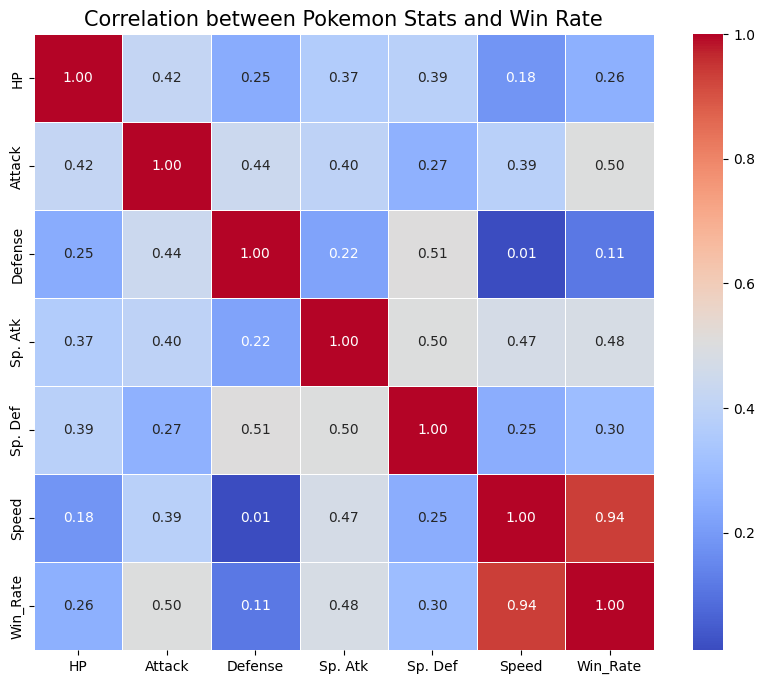

In [22]:
# "Create a correlation matrix to identify relationships between stats (HP, Attack, Speed) and win percentage. "
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Select the relevant columns
# We include the core stats and the Win_Rate we just calculated
stats_columns = ['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed', 'Win_Rate']
correlation_data = pokemon_with_winrate[stats_columns]

# 2. Calculate the correlation matrix
corr_matrix = correlation_data.corr()

# 3. Visualize with a Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Correlation between Pokemon Stats and Win Rate', fontsize=15)
plt.show()

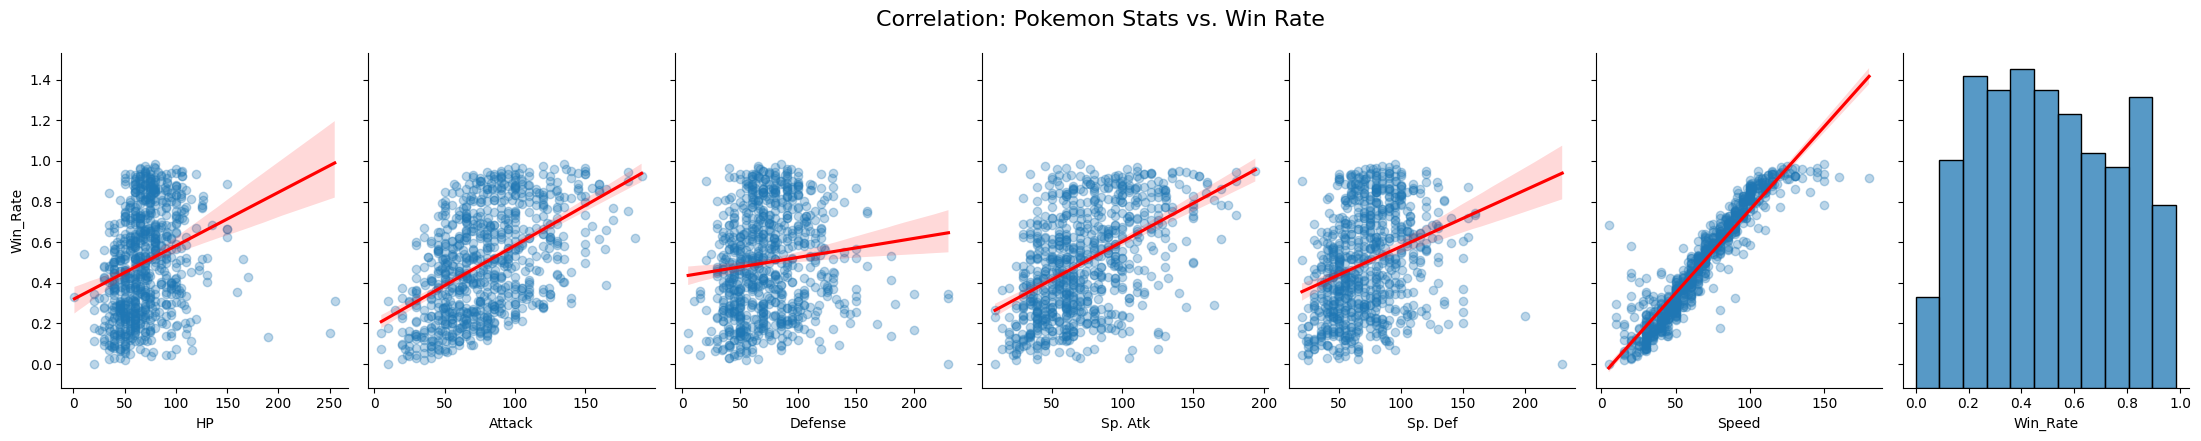

In [23]:
# Insight: Speed is the one stat that is highly correlated with Win Rate.
# "Plot a Seaborn pairplot or PairGrid for stats vs. win percentage. "
# 2. Create a PairPlot
# We use x_vars and y_vars to focus the grid specifically on stats vs win percentage
# kind='reg' adds a linear regression line to each plot to show the trend
pair_plot = sns.pairplot(
    pokemon_with_winrate, 
    x_vars=stats_columns, 
    y_vars=['Win_Rate'], 
    kind='reg', 
    height=4, 
    aspect=0.8,
    plot_kws={'line_kws':{'color':'red'}, 'scatter_kws': {'alpha': 0.3}}
)

# 3. Styling
plt.suptitle('Correlation: Pokemon Stats vs. Win Rate', y=1.08, fontsize=16)
plt.show()

In [24]:
# Insight: We see in the pairplot again that Speed is the one stat strongly correlated with Win Rate.
# "Analyze the top 10 Pokemon by win percentage and their stats. "
top_pokemons = pokemon_with_winrate.sort_values(by='Win_Rate', ascending=False)
print(top_pokemons[['Name', 'Win_Rate', 'HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed']].head(10))

                         Name  Win_Rate   HP  Attack  Defense  Sp. Atk  \
154           Mega Aerodactyl  0.984496   80     135       85       70   
512                   Weavile  0.974790   70     120       65       45   
703    Tornadus Therian Forme  0.968000   79     100       80      110   
19              Mega Beedrill  0.966387   65     150       40       15   
153                Aerodactyl  0.964539   80     105       65       60   
476              Mega Lopunny  0.961240   65     136       94       54   
726                  Greninja  0.960630   72      95       67      103   
716  Meloetta Pirouette Forme  0.959350  100     128       90       77   
164             Mega Mewtwo Y  0.952000  106     150       70      194   
349             Mega Sharpedo  0.950000   70     140       70      110   

     Sp. Def  Speed  
154       95    150  
512       85    125  
703       90    121  
19        80    145  
153       75    130  
476       96    135  
726       71    122  
716      

In [25]:
# We see the importance of speed in predicting win rate here again. Note the broad variety of Sp. Def, HP, Defense, and Sp. Atk numbers among these top ten. However, Attack appears relatively high among these top ten, which coincides with the correlation plot showing Attack correlating moderately with Win Rate, though still much less than Speed.

# "Machine Learning

#     Split data into training/testing sets (80/20 split). "
# The models will be used to to predict win percentage. So y will be win_rate. What will be X?
# Reviewing relevant columns:
pokemon_with_winrate.head()

,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary,Total_Fights,Total_Wins,Win_Rate
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False,133,37.0,0.278195
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,1,False,121,46.0,0.380165
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,1,False,132,89.0,0.674242
3,4,Mega Venusaur,Grass,Poison,80,100,123,122,120,80,1,False,125,70.0,0.560000
4,5,Charmander,Fire,None,39,52,43,60,50,65,1,False,112,55.0,0.491071


In [26]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, classification_report, roc_auc_score, confusion_matrix
from sklearn.linear_model import LinearRegression
# Preparation for modeling:
# y: 'Win_Rate
# Irrelevant columns: #, Name, Total_Fights, Total_Wins
df = pokemon_with_winrate.copy()
df['Legendary'] = pd.to_numeric(df['Legendary'])
df = pd.get_dummies(df, columns=['Type 1', 'Type 2'], drop_first=True)
X = df.drop(columns=['#','Name','Total_Fights', 'Total_Wins'
])
y = df['Win_Rate']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [29]:
# "Train and evaluate 3 regression models (e.g., Linear Regression, Random Forest, XGBoost) to predict win percentage. "
# Multiple Linear Regression:

# Fit multiple linear regression
model_lr = LinearRegression()
model_lr.fit(X_train_scaled, y_train)

# Predict and evaluate
y_pred_lr = model_lr.predict(X_test_scaled)

r2_lr = r2_score(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)

print("=== Multiple Linear Regression ===")
print(f"R-squared: {r2_lr:.4f}")
print(f"RMSE:      {rmse_lr:.4f}")
print(f"MAE:       {mae_lr:.4f}")

=== Multiple Linear Regression ===
R-squared: 1.0000
RMSE:      0.0000
MAE:       0.0000


In [33]:
feature_names = X.columns
coefs = model_lr.coef_
display(feature_names)
display(coefs)

Index(['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed', 'Generation',
       'Legendary', 'Win_Rate', 'Type 1_Dark', 'Type 1_Dragon',
       'Type 1_Electric', 'Type 1_Fairy', 'Type 1_Fighting', 'Type 1_Fire',
       'Type 1_Flying', 'Type 1_Ghost', 'Type 1_Grass', 'Type 1_Ground',
       'Type 1_Ice', 'Type 1_Normal', 'Type 1_Poison', 'Type 1_Psychic',
       'Type 1_Rock', 'Type 1_Steel', 'Type 1_Water', 'Type 2_Dark',
       'Type 2_Dragon', 'Type 2_Electric', 'Type 2_Fairy', 'Type 2_Fighting',
       'Type 2_Fire', 'Type 2_Flying', 'Type 2_Ghost', 'Type 2_Grass',
       'Type 2_Ground', 'Type 2_Ice', 'Type 2_None', 'Type 2_Normal',
       'Type 2_Poison', 'Type 2_Psychic', 'Type 2_Rock', 'Type 2_Steel',
       'Type 2_Water'],
      dtype='str')

array([-1.40150393e-16,  4.30211422e-16,  9.22257141e-17,  1.58466731e-16,
        1.58008075e-16,  1.90916197e-16,  1.41024535e-16,  8.07952630e-17,
        2.54434021e-01, -1.10434966e-17,  1.32109264e-17, -4.08835534e-17,
        2.22236791e-17, -9.56712669e-17, -5.36687894e-17,  7.92118349e-17,
        7.52611467e-17, -1.51208362e-16, -4.84036784e-17, -2.83350307e-17,
       -7.44997678e-18, -8.63651050e-17,  9.12879174e-17, -9.34652567e-19,
        2.50443516e-17, -9.68703473e-17, -4.52009946e-17, -4.26262604e-17,
        5.74312844e-17, -1.00237828e-16, -9.34764719e-17, -7.08858526e-17,
       -1.08540529e-16, -1.26634814e-16, -1.12323345e-16,  3.64291930e-17,
        1.02348685e-16, -2.82759927e-16, -8.91214186e-17, -1.08420217e-16,
       -8.67361738e-18, -4.84502846e-17, -1.27502175e-16, -1.00613962e-16])